<a href="https://colab.research.google.com/github/FajarWahyuSuryaputra/2025_pengolahan_citra_TI2B/blob/main/Minggu04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float, util, filters, morphology
from scipy import ndimage as ndi

## Praktikum 01
### Transformasi Kurva(Citra Negatif)

In [2]:
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)

negative_gray = 1.0 - image_gray_float

In [ ]:
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)

negative_color = 1.0 - image_color_float

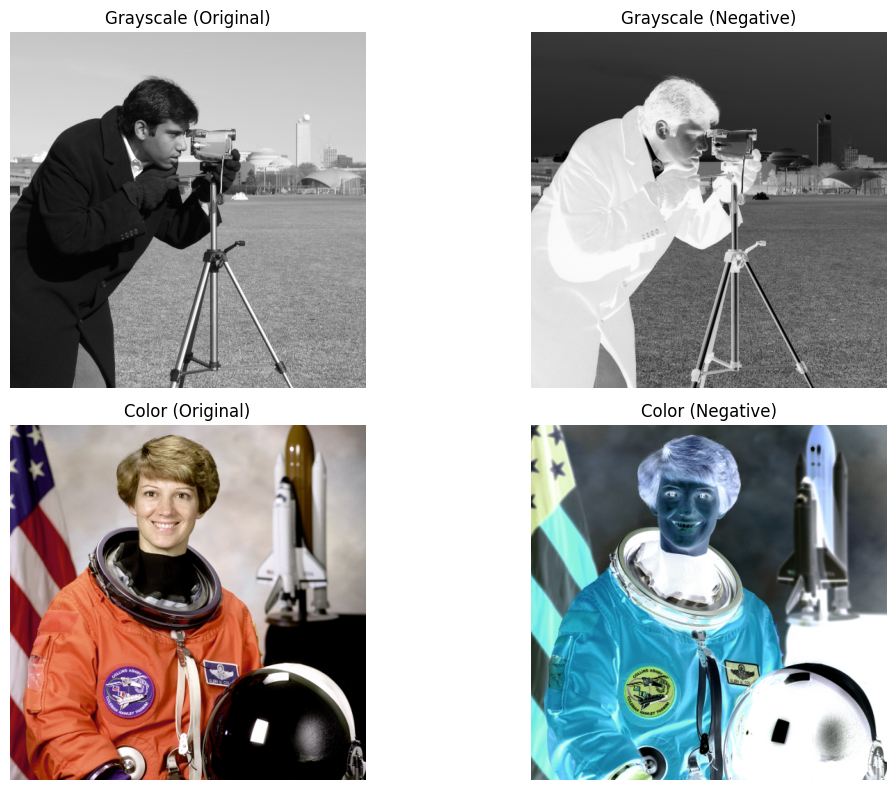

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title('Grayscale (Negative)')
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title('Color (Original)')
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title('Color (Negative)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 02
###Histogram dan Ekualisasi Histogram

####Bagian1

In [ ]:
hist_gray, bins_gray = np.histogram(
    image_gray_float.ravel(), bins=256, range=(0, 1))

In [ ]:
image_gray_eq = exposure.equalize_hist(image_gray_float)
hist_gray_eq, bins_gray_eq = np.histogram(
    image_gray_eq.ravel(), bins=256, range=(0, 1))

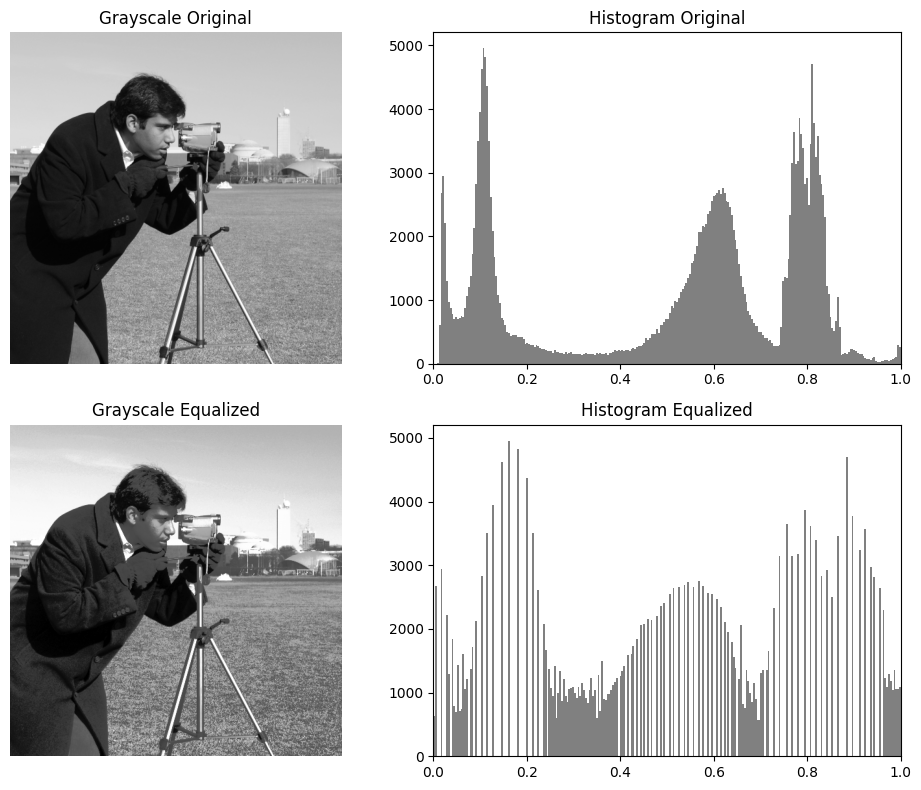

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale Original')
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray_float.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title('Histogram Original')
axes[0, 1].set_xlim(0, 1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title('Grayscale Equalized')
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title('Histogram Equalized')
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

####Bagian2

In [ ]:
r_channel = image_color_float[:, :, 0]
g_channel = image_color_float[:, :, 1]
b_channel = image_color_float[:, :, 2]

In [ ]:
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

In [ ]:
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

In [ ]:
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

In [ ]:
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

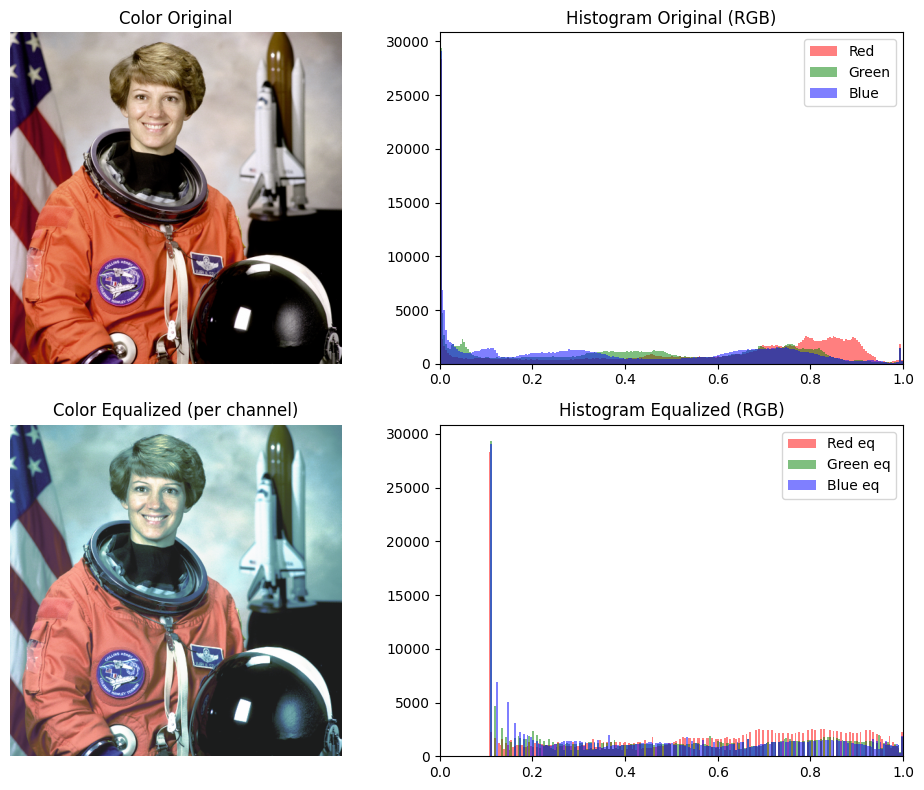

In [ ]:
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(image_color_float)
axes2[0, 0].set_title('Color Original')
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title('Histogram Original (RGB)')
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title('Color Equalized (per channel)')
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title('Histogram Equalized (RGB)')
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

##Praktikum 03
###Konvolusi (Filter Rata-Rata)

####Citra Grayscale

In [ ]:
kernel_size = 5
kernel = np.ones(
    (kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

In [ ]:
gray_filtered = ndi.convolve(image_gray_float, kernel, mode='reflect')

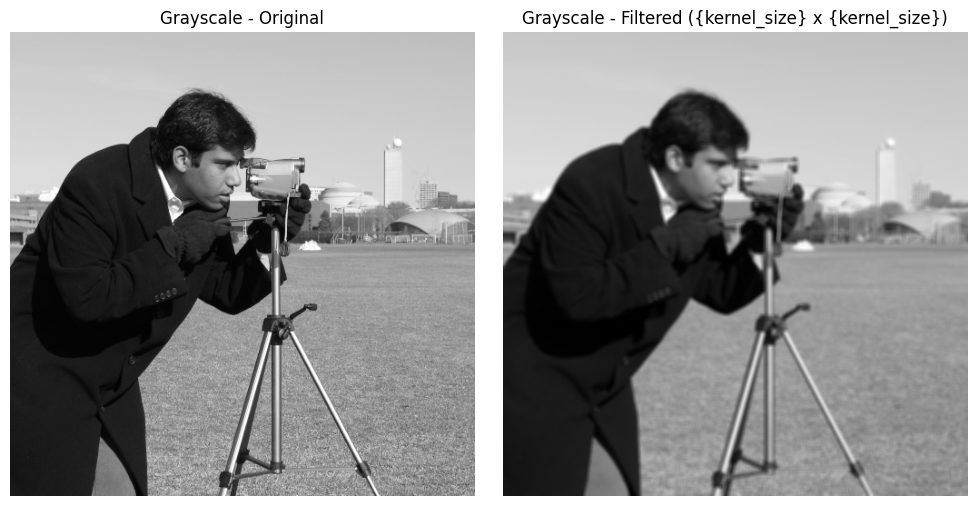

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_gray_float, cmap='gray')
axes[0].set_title('Grayscale - Original')
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title('Grayscale - Filtered ({kernel_size} x {kernel_size})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

####Citra Berwarna

In [ ]:
color_filtered = np.zeros_like(image_color_float)

for c in range(3):
  channel_original = image_color_float[:, :, c]
  channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
  color_filtered[:, :, c] = channel_filtered

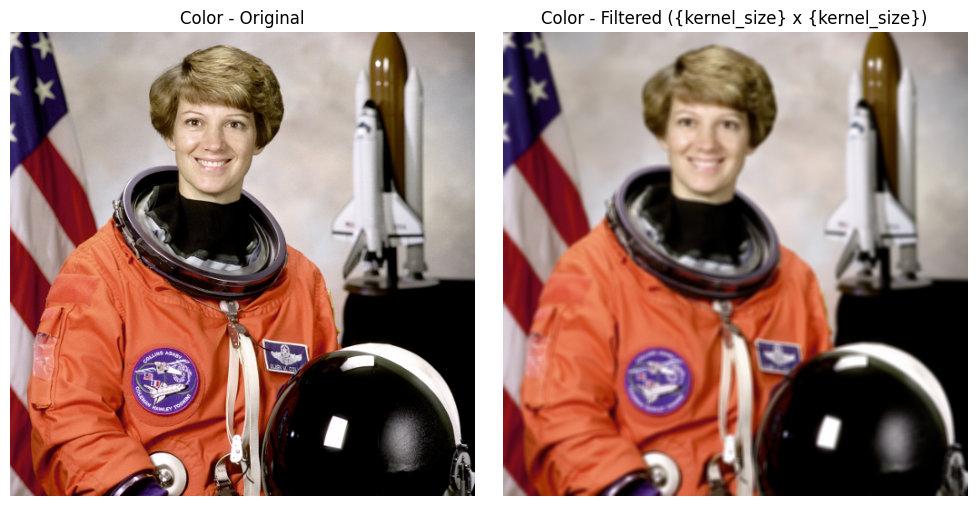

In [ ]:
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(image_color_float)
axes2[0].set_title('Color - Original')
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title('Color - Filtered ({kernel_size} x {kernel_size})')
axes2[1].axis('off')

plt.tight_layout()
plt.show()

##Praktikum 04
###Filter Median (penghilangan noise/deran)

####Citra Grayscale

In [ ]:
gray_noisy = util.random_noise(image_gray_float, mode='s&p', amount=0.05)

In [ ]:
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

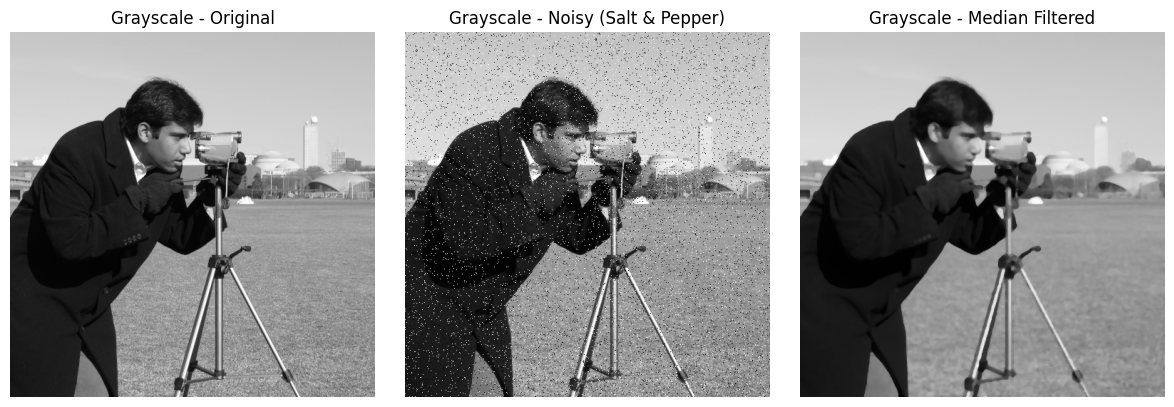

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image_gray_float, cmap='gray')
axes[0].set_title('Grayscale - Original')
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title('Grayscale - Noisy (Salt & Pepper)')
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title('Grayscale - Median Filtered')
axes[2].axis('off')

plt.tight_layout()
plt.show()

####Citra Berwarna

In [ ]:
color_noisy = util.random_noise(image_color_float, mode='s&p', amount=0.05)

In [ ]:
color_denoised = np.zeros_like(color_noisy)

for c in range(color_noisy.shape[2]):
  color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

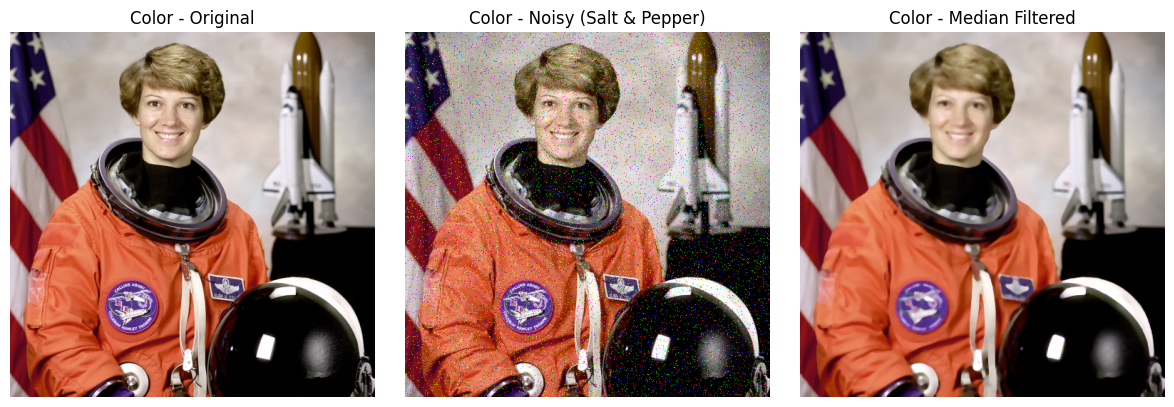

In [ ]:
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))

axes2[0].imshow(image_color_float)
axes2[0].set_title('Color - Original')
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title('Color - Noisy (Salt & Pepper)')
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title('Color - Median Filtered')
axes2[2].axis('off')

plt.tight_layout()
plt.show()
#

##Tugas 01

In [ ]:
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)

gamma_gray = exposure.adjust_gamma(image_gray_float, 0.5)

In [ ]:
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)

gamma_color = exposure.adjust_gamma(image_color_float, 0.5)

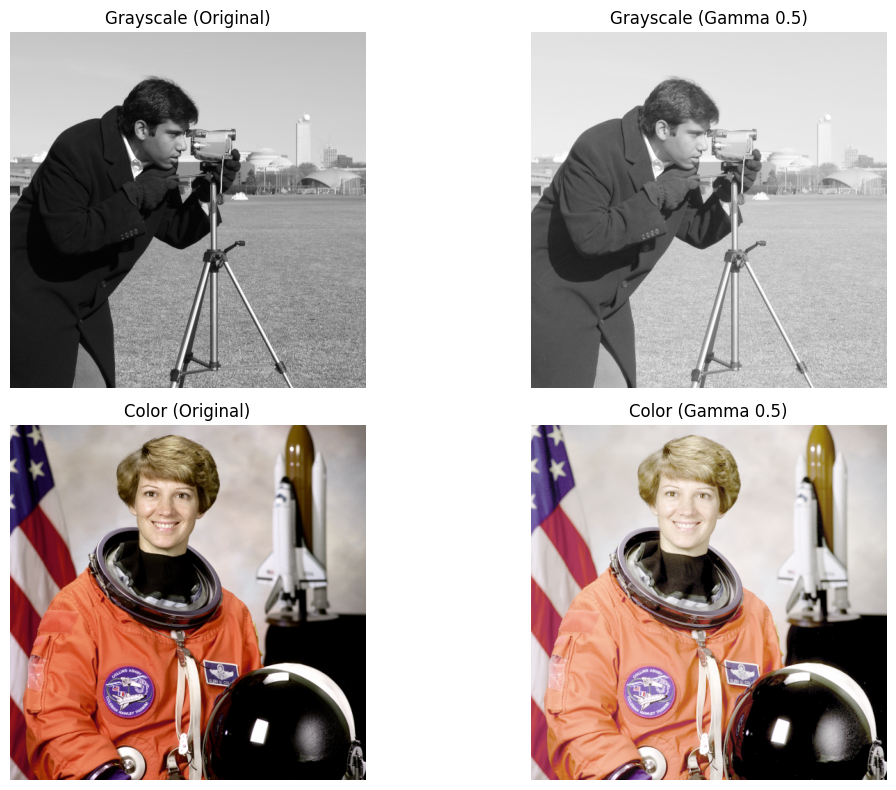

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(gamma_gray, cmap='gray')
axes[0, 1].set_title('Grayscale (Gamma 0.5)')
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float, cmap='gray')
axes[1, 0].set_title('Color (Original)')
axes[1, 0].axis('off')

axes[1, 1].imshow(gamma_color, cmap='gray')
axes[1, 1].set_title('Color (Gamma 0.5)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

##Tugas 02

In [ ]:
low_contrast_gray = exposure.rescale_intensity(image_gray_float, in_range=(0.2, 0.8))
hist_gray_lw, bins_gray_lw = np.histogram(
    low_contrast_gray.ravel(), bins=256, range=(0, 1))


image_gray_st = exposure.rescale_intensity(image_gray_float)
hist_gray_st, bins_gray_st = np.histogram(
    image_gray_st.ravel(), bins=256, range=(0, 1))

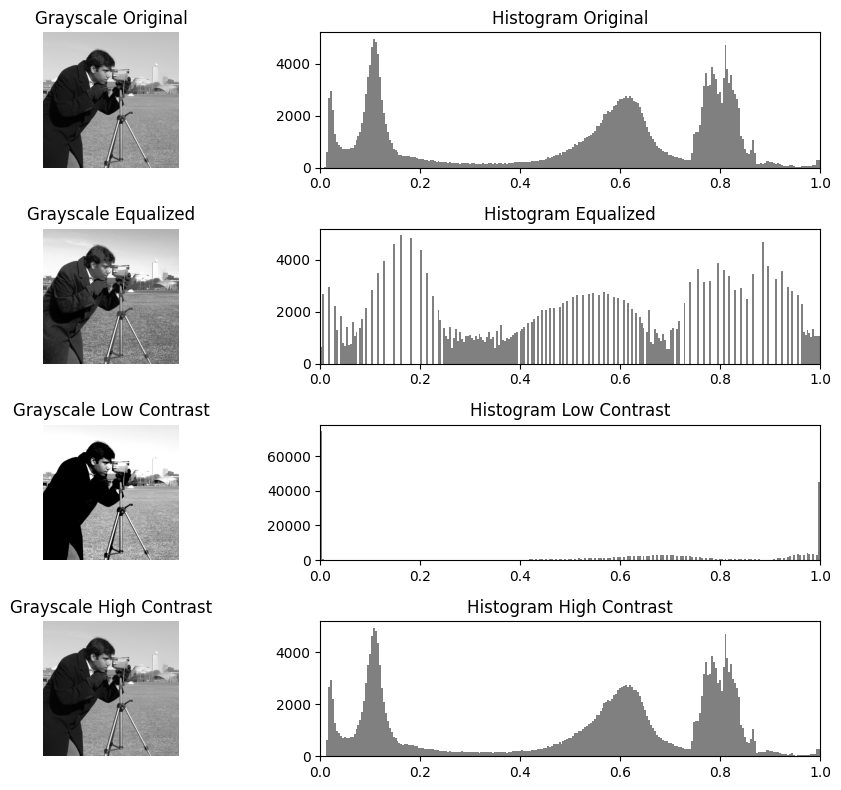

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale Original')
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray_float.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title('Histogram Original')
axes[0, 1].set_xlim(0, 1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title('Grayscale Equalized')
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title('Histogram Equalized')
axes[1, 1].set_xlim(0, 1)

axes[2, 0].imshow(low_contrast_gray, cmap='gray')
axes[2, 0].set_title('Grayscale Low Contrast')
axes[2, 0].axis('off')

axes[2, 1].hist(low_contrast_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[2, 1].set_title('Histogram Low Contrast')
axes[2, 1].set_xlim(0, 1)

axes[3, 0].imshow(image_gray_st, cmap='gray')
axes[3, 0].set_title('Grayscale High Contrast')
axes[3, 0].axis('off')

axes[3, 1].hist(image_gray_st.ravel(), bins=256, range=(0, 1), color='gray')
axes[3, 1].set_title('Histogram High Contrast')
axes[3, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

##Tugas 03

In [14]:
citra_noisy = util.random_noise(image_gray_float, mode='s&p', amount=0.05)

In [21]:
citra_filtered = ndi.uniform_filter(citra_noisy, size=3)

In [20]:
citra_denoised = ndi.median_filter(citra_noisy, size=3)

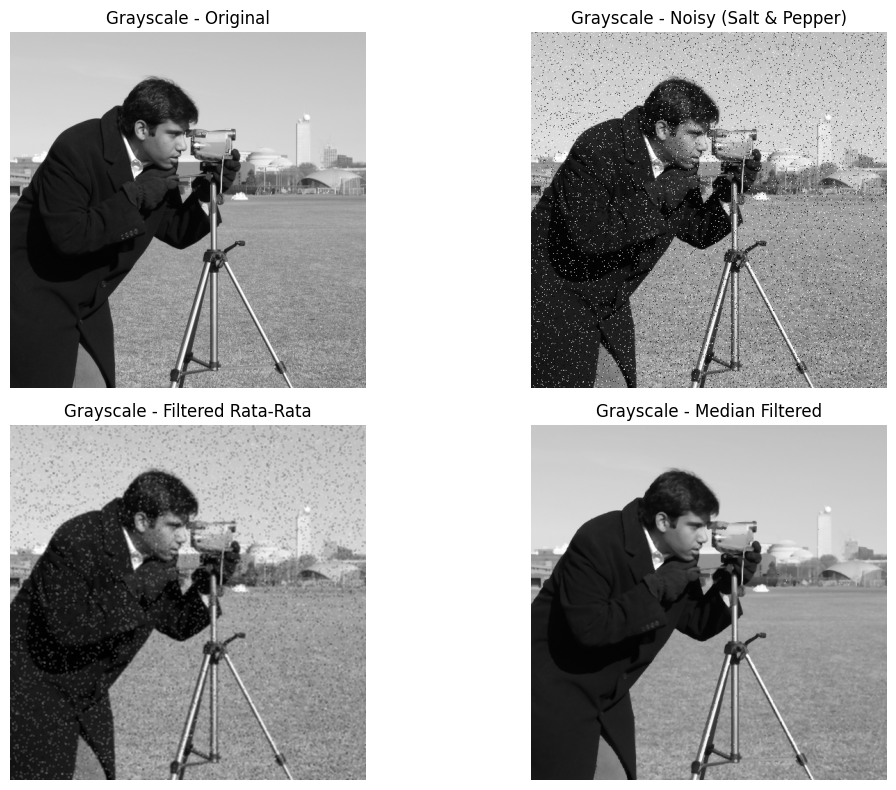

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title('Grayscale - Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(citra_noisy, cmap='gray')
axes[0, 1].set_title('Grayscale - Noisy (Salt & Pepper)')
axes[0, 1].axis('off')

axes[1, 0].imshow(citra_filtered, cmap='gray')
axes[1, 0].set_title('Grayscale - Filtered Rata-Rata')
axes[1, 0].axis('off')

axes[1, 1].imshow(citra_denoised, cmap='gray')
axes[1, 1].set_title('Grayscale - Median Filtered')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()